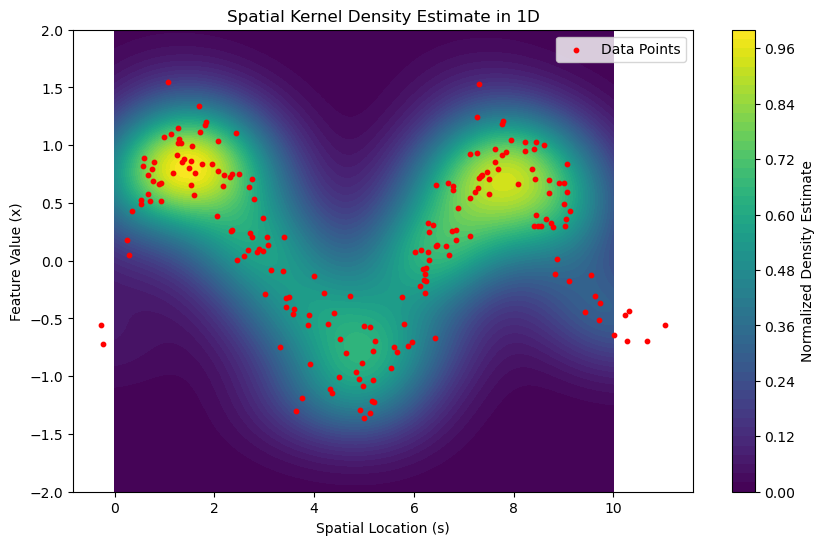

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Number of data points
n = 200

# Spatial locations (s), evenly spaced along a line with some randomness
np.random.seed(0)  # For reproducibility
s = np.linspace(0, 10, n) + np.random.normal(scale=0.5, size=n)

# Feature values (x), depending on spatial location with added noise
x = np.sin(s) + np.random.normal(scale=0.3, size=n)


# Define Gaussian kernel function
def gaussian_kernel(u, bandwidth):
    return norm.pdf(u / bandwidth) / bandwidth


# Grid points where we estimate the density
x_grid = np.linspace(-2, 2, 100)
s_grid = np.linspace(0, 10, 100)

# Bandwidths for feature and spatial dimensions
h = 0.3  # Bandwidth for x
theta = 1.0  # Bandwidth for s

# Create meshgrid for evaluation points
X_grid, S_grid = np.meshgrid(x_grid, s_grid)

# Flatten the grid for computation
X_grid_flat = X_grid.ravel()
S_grid_flat = S_grid.ravel()

# Initialize density estimates
density_estimates = np.zeros_like(X_grid_flat)

# Compute the density estimate at each grid point
for i in range(len(X_grid_flat)):
    # Differences in feature and spatial dimensions
    u_x = X_grid_flat[i] - x
    u_s = S_grid_flat[i] - s

    # Compute kernels
    K_x = gaussian_kernel(u_x, h)
    W_s = gaussian_kernel(u_s, theta)

    # Combine kernels
    weights = K_x * W_s

    # Density estimate at the grid point
    density_estimates[i] = np.sum(weights) / n

# Reshape density estimates back to grid shape
density_estimates = density_estimates.reshape(X_grid.shape)

# Normalize for visualization purposes
density_estimates /= np.max(density_estimates)

# Plot the results
plt.figure(figsize=(10, 6))
plt.contourf(S_grid, X_grid, density_estimates, levels=50, cmap="viridis")
plt.colorbar(label="Normalized Density Estimate")
plt.scatter(s, x, c="red", s=10, label="Data Points")
plt.xlabel("Spatial Location (s)")
plt.ylabel("Feature Value (x)")
plt.title("Spatial Kernel Density Estimate in 1D")
plt.legend()
plt.show()